Objetivo
Importar a base de dados
• Verificar informações vazias
• Fazer o tratamento na base de dados
• Selecionar as colunas de treino para o modelo
• Treinar 2 modelos
• Verificar o melhor modelo
• Verificar quais as características mais importantes para definir o score do cliente

In [1]:
# %pip install pandas

import pandas as pd

tabela = pd.read_csv('clientes.csv') #importa a base de dados
display(tabela) #exibe a base de dados



,id_cliente,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,3392,1,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,265.0,21.465380,alto_gasto_pagamento_baixos,312.494089,Good,1,1,1,1,0
1,3392,2,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,266.0,21.465380,baixo_gasto_pagamento_alto,284.629162,Good,1,1,1,1,0
2,3392,3,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,267.0,21.465380,baixo_gasto_pagamento_medio,331.209863,Good,1,1,1,1,0
3,3392,4,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,5.0,...,268.0,21.465380,baixo_gasto_pagamento_baixo,223.451310,Good,1,1,1,1,0
4,3392,5,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,6.0,...,269.0,21.465380,alto_gasto_pagamento_medio,341.489231,Good,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,37932,4,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,23.0,...,378.0,24.028477,alto_gasto_pagamento_alto,479.866228,Poor,1,0,0,0,1
99996,37932,5,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,18.0,...,379.0,24.028477,alto_gasto_pagamento_medio,496.651610,Poor,1,0,0,0,1
99997,37932,6,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,27.0,...,380.0,24.028477,alto_gasto_pagamento_alto,516.809083,Poor,1,0,0,0,1
99998,37932,7,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,20.0,...,381.0,24.028477,baixo_gasto_pagamento_alto,319.164979,Standard,1,0,0,0,1


In [2]:
print(tabela.info()) #exibe as informações da base de dados
print(tabela.columns) #exibe as colunas da base de dados
print(tabela.describe()) #exibe as estatísticas da base de dados

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  str    
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  str    
 13  divida_total              100000 non-null  float64
 14  

In [3]:
# %pip install -U scikit-learn
from sklearn.preprocessing import LabelEncoder
codificador = LabelEncoder() #cria o codificador

for coluna in tabela.columns:
    if tabela[coluna].dtype == 'str' and coluna != 'score_credito': #verifica se a coluna é do tipo object
        tabela[coluna] = codificador.fit_transform(tabela[coluna]) #codifica a coluna

for coluna in tabela.columns:
    if tabela[coluna].dtype == 'str' and coluna != 'score_credito': #verifica se a coluna é do tipo object
        print(coluna) #exibe os valores únicos de cada coluna


display(tabela) #exibe a base de dados codificada

,id_cliente,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,3392,1,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,...,265.0,21.465380,1,312.494089,Good,1,1,1,1,0
1,3392,2,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,...,266.0,21.465380,3,284.629162,Good,1,1,1,1,0
2,3392,3,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,...,267.0,21.465380,5,331.209863,Good,1,1,1,1,0
3,3392,4,23.0,2,19114.12,3.0,4.0,3.0,4.0,5.0,...,268.0,21.465380,4,223.451310,Good,1,1,1,1,0
4,3392,5,23.0,2,19114.12,3.0,4.0,3.0,4.0,6.0,...,269.0,21.465380,2,341.489231,Good,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,37932,4,25.0,11,39628.99,4.0,6.0,7.0,2.0,23.0,...,378.0,24.028477,0,479.866228,Poor,1,0,0,0,1
99996,37932,5,25.0,11,39628.99,4.0,6.0,7.0,2.0,18.0,...,379.0,24.028477,2,496.651610,Poor,1,0,0,0,1
99997,37932,6,25.0,11,39628.99,4.0,6.0,7.0,2.0,27.0,...,380.0,24.028477,0,516.809083,Poor,1,0,0,0,1
99998,37932,7,25.0,11,39628.99,4.0,6.0,7.0,2.0,20.0,...,381.0,24.028477,3,319.164979,Standard,1,0,0,0,1


In [4]:
# escolhendo as colunas que vamos usar para treinar o modelo
# y é a coluna que queremos que o modelo calcule
# x vai todas as colunas que vamos usar para prever o score de crédito, não vamos usar o id_cliente porque ele não tem relevância para o modelo prever o score de crédito
y = tabela['score_credito'] #coluna que queremos prever
x = tabela.drop(['id_cliente', 'score_credito'], axis=1) #colunas que vamos usar para prever o score de crédito

# train_test_split é uma função do scikit-learn que separa os dados em treino e teste, ela recebe como parâmetros os dados de entrada (x) e os dados de saída (y), o tamanho do teste (test_size) e a semente para randomização (random_state)
from sklearn.model_selection import train_test_split

#separamos os dados em treino e teste, 30% dos dados para teste e 70% para treino
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, random_state=2)

In [5]:
# O Random Forest é um modelo de aprendizado de máquina que utiliza várias árvores de decisão para fazer previsões. Ele é conhecido por ser um modelo robusto e preciso, especialmente em conjuntos de dados com muitas variáveis e interações complexas entre elas. O KNN (K-Nearest Neighbors) é um modelo de aprendizado de máquina que classifica os dados com base na proximidade dos pontos de dados. Ele é simples e fácil de entender, mas pode ser sensível a ruídos e outliers nos dados.
from sklearn.ensemble import RandomForestClassifier
modelo_arvore = RandomForestClassifier() #cria o modelo árvore de decisão

from sklearn.neighbors import KNeighborsClassifier
modelo_knn = KNeighborsClassifier() #cria o modelo KNN (nearest neighbors)

#treinando os modelos
modelo_arvore.fit(x_treino, y_treino) #treina o modelo árvore de decisão
modelo_knn.fit(x_treino, y_treino) #treina o modelo KNN (nearest neighbors)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [6]:
# se o modelo chutasse tudo "Standard", qual seria a acurácia do modelo?
contagem_scores = tabela['score_credito'].value_counts() #conta a quantidade de cada valor na coluna score_credito
print(contagem_scores['Standard'] / sum(contagem_scores)) #exibe a contagem de cada valor na coluna score_credito

0.53174


/Users/gilnanderson/Documents/Gil/Documentos/2026/Aulas_Python/Aula 3 - Projeto de Previsão com Machine Learning/Exercicio/.conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Acurácia do modelo árvore de decisão: 82.33
Acurácia do modelo KNN: 73.63666666666666


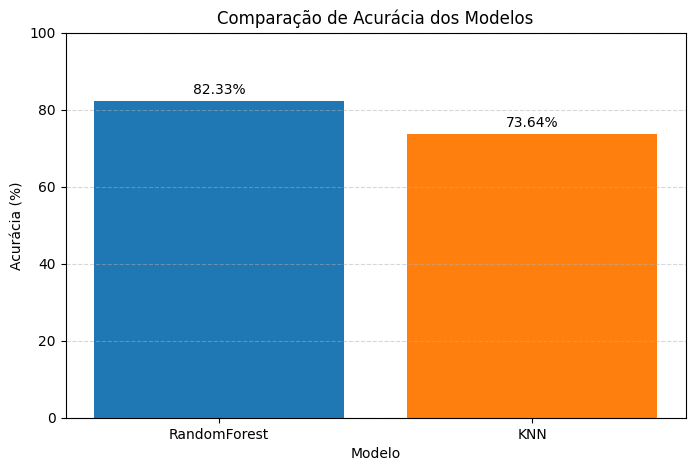

In [7]:
# importando a função para calcular a acurácia dos modelos
from sklearn.metrics import accuracy_score

#%pip install matplotlib

# calculamos as previsões dos modelos
previsoes_arvore = modelo_arvore.predict(x_teste) #previsões do modelo árvore de decisão
previsoes_knn = modelo_knn.predict(x_teste.to_numpy()) #previsões do modelo KNN (nearest neighbors), convertendo x_teste para numpy array

#comparamos as previsões com o y_teste para calcular a acurácia dos modelos
#score deve ser maior que 0.5 para o modelo ser considerado bom, ou seja, o modelo deve acertar mais de 50% das previsões
acuracia_arvore = accuracy_score(y_teste, previsoes_arvore)
acuracia_knn = accuracy_score(y_teste, previsoes_knn)

acuracia_arvore_pct = acuracia_arvore * 100
acuracia_knn_pct = acuracia_knn * 100

print('Acurácia do modelo árvore de decisão:', acuracia_arvore_pct) #exibe a acurácia do modelo árvore de decisão
print('Acurácia do modelo KNN:', acuracia_knn_pct) #exibe a acurácia do modelo KNN (nearest neighbors)

# gráfico comparando acurácia dos modelos
import matplotlib.pyplot as plt

modelos = ['RandomForest', 'KNN']
acuracias = [acuracia_arvore_pct, acuracia_knn_pct]

plt.figure(figsize=(8, 5))
plt.bar(modelos, acuracias, color=['#1f77b4', '#ff7f0e'])
plt.ylim(0, 100)
plt.title('Comparação de Acurácia dos Modelos')
plt.ylabel('Acurácia (%)')
plt.xlabel('Modelo')
for i, valor in enumerate(acuracias):
    plt.text(i, valor + 1, f'{valor:.2f}%'
, ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



Ranking de Importância das Características:


,coluna,importancia_pct
0,divida_total,11.43%
1,juros_emprestimo,8.41%
2,mix_credito,8.15%
3,idade_historico_credito,7.55%
4,dias_atraso,6.62%
5,saldo_final_mes,5.45%
6,taxa_uso_credito,5.11%
7,salario_anual,5.09%
8,investimento_mensal,4.86%
9,num_pagamentos_atrasados,4.62%


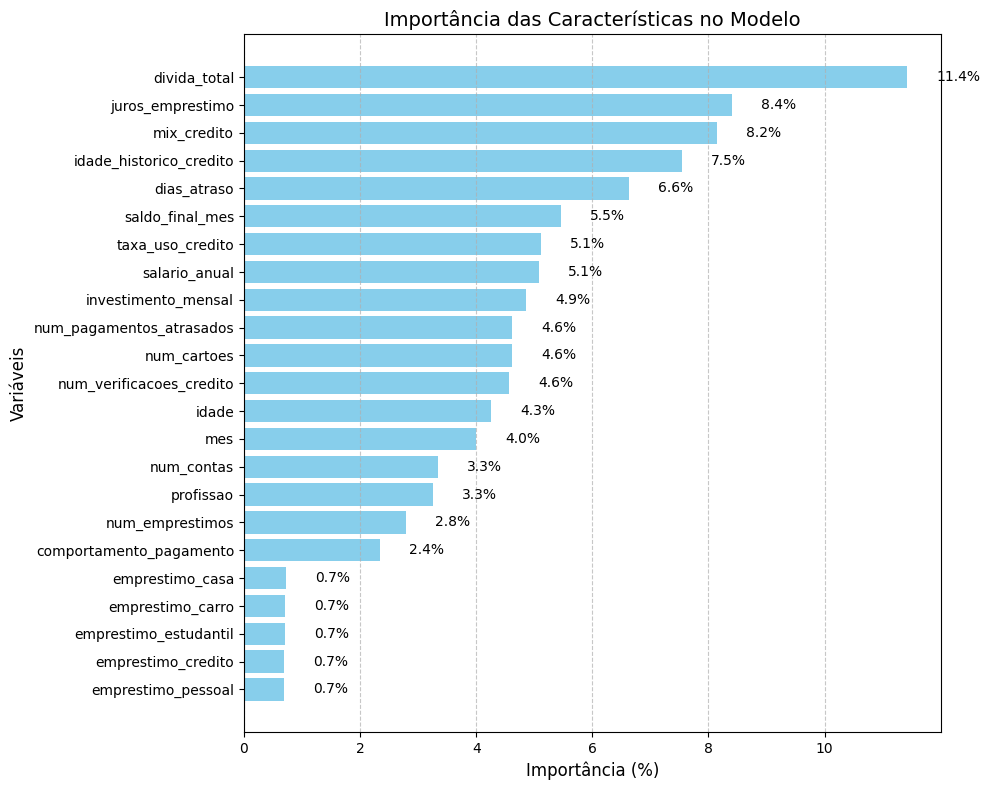

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Criar e preparar o DataFrame de importância
colunas = list(x_teste.columns)
importancia_colunas = pd.DataFrame({
    'coluna': colunas, 
    'importancia': modelo_arvore.feature_importances_
})

# 1. Preparação dos dados
importancia_colunas['importancia_pct'] = importancia_colunas['importancia'].fillna(0) * 100
importancia_colunas = importancia_colunas.sort_values(by='importancia_pct', ascending=False)

# 2. Exibição da Tabela com Formatação (Tratamento Visual)
print("Ranking de Importância das Características:")

# Criamos uma cópia formatada para exibição
tabela_formatada = importancia_colunas[['coluna', 'importancia_pct']].copy()

# Opção A: Arredondar os valores para 2 casas decimais
tabela_formatada['importancia_pct'] = tabela_formatada['importancia_pct'].round(2)

# Opção B: Adicionar o símbolo de % (transforma em string para o display)
tabela_formatada['importancia_pct'] = tabela_formatada['importancia_pct'].apply(lambda x: f"{x:.2f}%")

display(tabela_formatada.reset_index(drop=True))

# 3. Gerar o Gráfico
plt.figure(figsize=(10, 8))

# Criar barras horizontais
bars = plt.barh(importancia_colunas['coluna'], importancia_colunas['importancia_pct'], color='skyblue')

# Inverter o eixo Y para que a maior barra fique no topo
plt.gca().invert_yaxis()

# Adicionar os rótulos de texto (os valores % ao lado das barras)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontsize=10)

# Estilização final
plt.title('Importância das Características no Modelo', fontsize=14)
plt.xlabel('Importância (%)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

--- Ranking de Importância das Variáveis ---


,Variável,Importância (%)
0,divida_total,11.43%
1,juros_emprestimo,8.41%
2,mix_credito,8.15%
3,idade_historico_credito,7.55%
4,dias_atraso,6.62%
5,saldo_final_mes,5.45%
6,taxa_uso_credito,5.11%
7,salario_anual,5.09%
8,investimento_mensal,4.86%
9,num_pagamentos_atrasados,4.62%


/var/folders/_2/7fjh2s5j0c91ggpl_p4bj3lc0000gn/T/ipykernel_98189/2910871071.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cores = plt.cm.get_cmap('viridis')(importancia_colunas['Importância (%)'] / importancia_colunas['Importância (%)'].max())


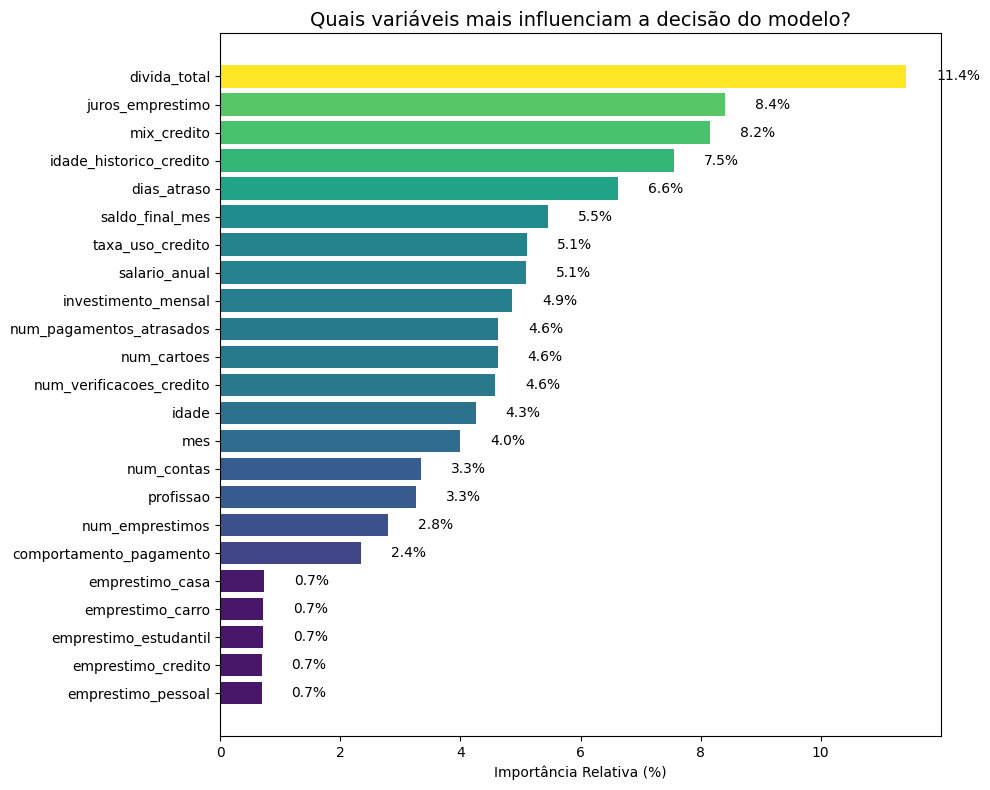

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparação dos Dados (igual ao anterior)
colunas = list(x_teste.columns)
importancia_colunas = pd.DataFrame({
    'Variável': colunas, 
    'Importância': modelo_arvore.feature_importances_
})

importancia_colunas['Importância (%)'] = importancia_colunas['Importância'].fillna(0) * 100
importancia_colunas = importancia_colunas.sort_values(by='Importância (%)', ascending=False).reset_index(drop=True)

# 2. Exibição da Tabela Tratada (VERSÃO COMPATÍVEL)
print("--- Ranking de Importância das Variáveis ---")

# Criamos uma cópia apenas para exibição com os valores já formatados como texto
tabela_print = importancia_colunas[['Variável', 'Importância (%)']].copy()
tabela_print['Importância (%)'] = tabela_print['Importância (%)'].map('{:.2f}%'.format)

display(tabela_print)

# 3. Gerar o Gráfico de Barras (igual ao anterior)
plt.figure(figsize=(10, 8))
cores = plt.cm.get_cmap('viridis')(importancia_colunas['Importância (%)'] / importancia_colunas['Importância (%)'].max())
bars = plt.barh(importancia_colunas['Variável'], importancia_colunas['Importância (%)'], color=cores)

plt.gca().invert_yaxis() 
plt.xlabel('Importância Relativa (%)')
plt.title('Quais variáveis mais influenciam a decisão do modelo?', fontsize=14)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center')

plt.tight_layout()
plt.show()

In [21]:
# --- BLOCO ADICIONAL: PREVISÃO DE NOVOS CLIENTES (VERSÃO CORRIGIDA) ---

# 1. Carregar os novos dados
novos_clientes = pd.read_csv('novos_clientes.csv')
tabela_exibicao = novos_clientes.copy()

# 2. Preparar os dados
# Em vez de criar um novo codificador, vamos usar a mesma lógica do treino
# Se você tiver muitas colunas, este loop garante que tudo que é texto vire número
from sklearn.preprocessing import LabelEncoder
codificador_especifico = LabelEncoder()

for coluna in novos_clientes.columns:
    # Verifica se a coluna é de texto (object)
    if novos_clientes[coluna].dtype == 'str' and coluna != 'score_credito': # 'score_credito' não deve existir aqui, mas é uma precaução
        novos_clientes[coluna] = codificador_especifico.fit_transform(novos_clientes[coluna])

# 3. Alinhamento de Colunas
# Garante que as colunas enviadas para o modelo sejam EXATAMENTE as que ele viu no treino
x_novos = novos_clientes[x.columns] # 'x' é o DataFrame de treino do bloco anterior

# 4. Realizar a Previsão
previsoes = modelo_arvore.predict(x_novos)

# 5. Exibir os resultados
tabela_exibicao['Previsão de Score'] = previsoes

print("--- Análise de Novos Clientes Concluída ---")
# display(tabela_exibicao[['profissao', 'salario_anual', 'mix_credito', 'Previsão de Score']])
# 1. Cria a função do padrão brasileiro
def formata_real(valor):
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# 2. Fazemos um filtro apenas com as colunas que queremos mostrar
tabela_final = tabela_exibicao[['profissao', 'salario_anual', 'mix_credito', 'Previsão de Score']].copy()

# 3. Aplicamos a formatação na coluna transformando os números em texto com o R$
tabela_final['salario_anual'] = tabela_final['salario_anual'].apply(formata_real)

# 4. Exibimos a tabela
display(tabela_final)

--- Análise de Novos Clientes Concluída ---


,profissao,salario_anual,mix_credito,Previsão de Score
0,empresario,"R$ 19.300,34",Ruim,Poor
1,advogado,"R$ 12.600,44",Normal,Standard
2,empresario,"R$ 20.787,69",Normal,Good
